# Dataset Exploration
Shows what a sample looks like for each dataset used in this project:
- **ICL UCR** — univariate time series classification from the UCR archive
- **ICL TSE** — TimeSeriesExam question templates re-cast as ICL classification

In [44]:
import sys
import os

# Add project root to path so local modules are importable
PROJECT_ROOT = os.path.abspath(".")
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from types import SimpleNamespace

---
## 1. ICL UCR — GunPoint

A 2-class dataset: `GunPoint` vs `Gun-Draw`. Each time series has 150 time steps.
We load the train split, display one sample per class, then build a 1-shot ICL prompt.

In [45]:
from data_provider.dataset_iclucr import UCRDataset

UCR_ROOT = "/cs/azencot_fsas/multimodal_ts/datasets/Univariate_arff"
DATASET_NAME = "GunPoint"

ucr_train = UCRDataset(os.path.join(UCR_ROOT, DATASET_NAME), split="train")
ucr_test  = UCRDataset(os.path.join(UCR_ROOT, DATASET_NAME), split="test")

print(f"Train samples : {len(ucr_train)}")
print(f"Test  samples : {len(ucr_test)}")
print(f"Series length : {ucr_train.data.shape[1]}")
print(f"Unique labels : {ucr_train.labels.unique().tolist()}")

Train samples : 50
Test  samples : 150
Series length : 150
Unique labels : [1, 2]


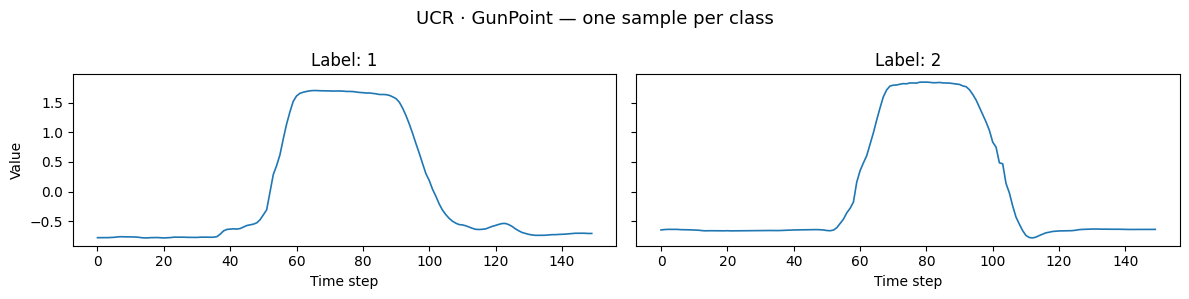

In [46]:
# Collect one example per class
unique_labels = ucr_train.labels.unique().tolist()
examples_by_label = {}
for i in range(len(ucr_train)):
    ts, label = ucr_train[i]
    lv = label.item()
    if lv not in examples_by_label:
        examples_by_label[lv] = ts.numpy()
    if len(examples_by_label) == len(unique_labels):
        break

fig, axes = plt.subplots(1, len(unique_labels), figsize=(12, 3), sharey=True)
fig.suptitle(f"UCR · {DATASET_NAME} — one sample per class", fontsize=13)
for ax, (label, ts) in zip(axes, sorted(examples_by_label.items())):
    ax.plot(ts, linewidth=1.2)
    ax.set_title(f"Label: {label}")
    ax.set_xlabel("Time step")
axes[0].set_ylabel("Value")
plt.tight_layout()
plt.show()

In [47]:
# Build a 1-shot ICL prompt and show the first test sample
from data_provider.icl_dataset import ICLUCRDataset

args_ucr = SimpleNamespace(
    picking_strategy="first",
    num_shots=1,
    random_seed=0,
    use_label_desc=0,
    desc_dir="ucr_descriptions",
    num_samples=5,
    input_mode="combined",
)

icl_ucr = ICLUCRDataset.from_ucr_dataset(
    ucr_train, ucr_test,
    task_id=f"icl_ucr_{DATASET_NAME}",
    args=args_ucr,
)

print(f"ICL dataset size: {len(icl_ucr)} samples")
sample = icl_ucr[0]
print(f"Keys: {list(sample.keys())}")

ICL dataset size: 5 samples
Keys: ['input_text', 'output_text', 'input_ts', 'task_id', 'options', 'mean', 'std']


In [48]:
# Show the full ICL prompt for the first test sample
print("=== ICL UCR PROMPT (first test sample) ===")
print(f"Ground-truth label : {sample['output_text']}")
print(f"Options            : {sample['options']}")
print()
# Truncate long TS arrays for readability
prompt_display = sample['input_text']
# Shorten embedded arrays to first 8 values
import re
def shorten_array(m):
    vals = m.group(1).split(", ")
    short = ", ".join(vals[:8]) + (f", ... ({len(vals)} values)" if len(vals) > 8 else "")
    return f"[{short}]"
prompt_display = re.sub(r"\[([^\[\]]+)\]", shorten_array, prompt_display)
print(prompt_display)

=== ICL UCR PROMPT (first test sample) ===
Ground-truth label : 1
Options            : ['1', '2']

Time Series Classification.


--- EXAMPLES ---

Example 1 Time Series: [-0.6479, -0.6420, -0.6382, -0.6383, -0.6383, -0.6387, -0.6430, -0.6438, ... (150 values)]
Label: 2

Example 2 Time Series: [-0.7784, -0.7783, -0.7772, -0.7777, -0.7759, -0.7724, -0.7655, -0.7623, ... (150 values)]
Label: 1

--- TARGET ---
New Time Series: [-0.8301, -0.8260, -0.8255, -0.8241, -0.8198, -0.8182, -0.8136, -0.8066, ... (150 values)]
Return ONLY the label as one of: [1, 2] without any explanation



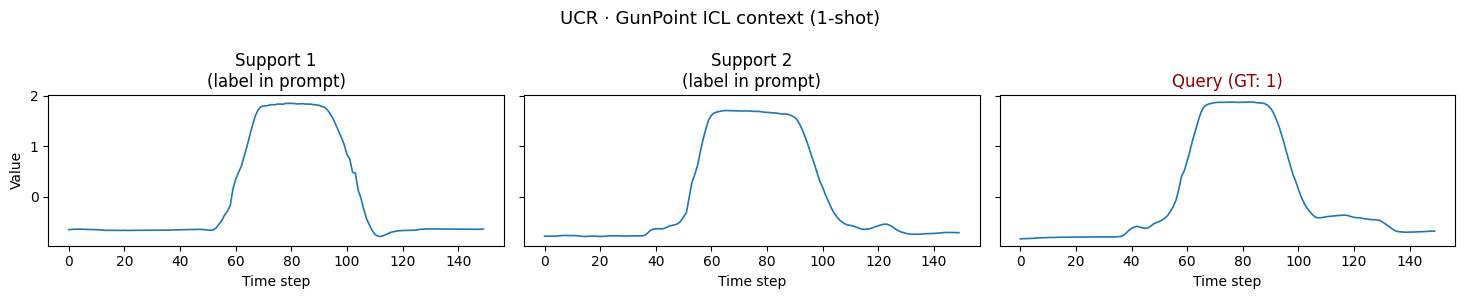

In [49]:
# Visualise the full ICL context: support time series + query
ts_list = sample['input_ts']   # list of raw float arrays
n_support = len(ts_list) - 1   # last one is the query

fig, axes = plt.subplots(1, len(ts_list), figsize=(5 * len(ts_list), 3), sharey=True)
if len(ts_list) == 1:
    axes = [axes]
fig.suptitle(f"UCR · {DATASET_NAME} ICL context (1-shot)", fontsize=13)

for i, (ax, ts) in enumerate(zip(axes, ts_list)):
    inner = ts[0] if isinstance(ts[0], list) else ts
    ax.plot(inner, linewidth=1.2)
    if i < n_support:
        # retrieve label from the text
        ax.set_title(f"Support {i+1}\n(label in prompt)")
    else:
        ax.set_title(f"Query (GT: {sample['output_text']})", color="darkred")
    ax.set_xlabel("Time step")
axes[0].set_ylabel("Value")
plt.tight_layout()
plt.show()

---
## 2. ICL TSE — TimeSeriesExam

We load two templates from `qa_dataset_augmented.json`:
- **tid=1** — "What is the type of trend?"
- **tid=65** — "What is the most likely type of anomaly?"

We show raw variants per class and a 1-shot ICL prompt for each.

In [50]:
TSE_PATH = "qa_dataset_augmented.json"

# Quick sanity check: which tids are in the file?
with open(TSE_PATH) as f:
    tse_entries = json.load(f)

tids_available = sorted(e["tid"] for e in tse_entries)
print(f"Available tids ({len(tids_available)}): {tids_available}")

Available tids (3): [1, 3, 65]


### 2a. Single-series template (tid=1)

In [51]:
from data_provider.dataset_tse import TimeSeriesExamDataset

TID = 1

tse_train = TimeSeriesExamDataset(TSE_PATH, tid=TID, split="train", test_fraction=0.3, seed=42)
tse_test  = TimeSeriesExamDataset(TSE_PATH, tid=TID, split="test",  test_fraction=0.3, seed=42)

print(f"tid={TID} | Train: {len(tse_train)} | Test: {len(tse_test)}")
print(f"is_two_series : {tse_train.is_two_series}")
print(f"label_names   : {tse_train.label_names}")
print(f"option_texts  : {tse_train.option_texts}")
print()
print("Description injected with --use_label_desc 1:")
print(tse_train.desc)

tid=1 | Train: 9 | Test: 6
is_two_series : False
label_names   : ['A', 'B', 'C']
option_texts  : ['Linear', 'Exponential', 'No Trend']

Description injected with --use_label_desc 1:
Question: What is the type of the trend of the given time series?

Options:
A) Linear
B) Exponential
C) No Trend


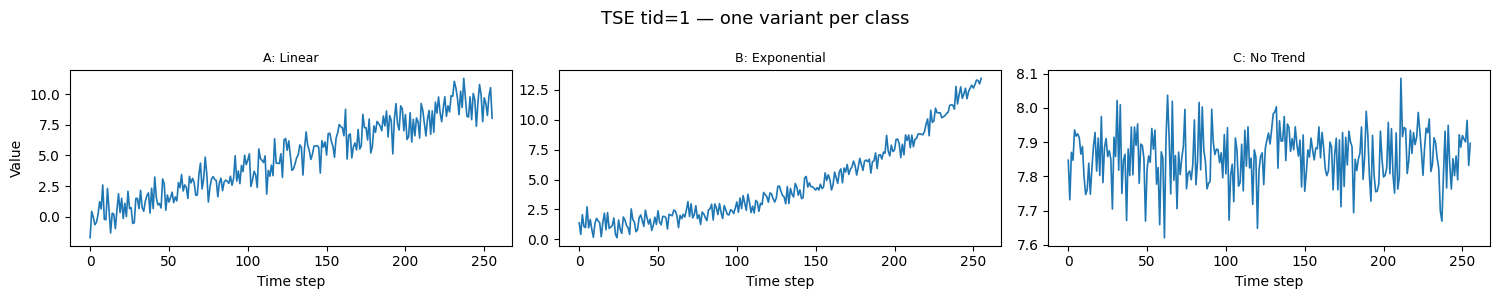

In [52]:
# One sample per class
seen = {}
for i in range(len(tse_train)):
    ts, label = tse_train[i]
    lv = label.item()
    if lv not in seen:
        seen[lv] = ts.numpy()
    if len(seen) == len(tse_train.label_names):
        break

fig, axes = plt.subplots(1, len(seen), figsize=(5 * len(seen), 3), sharey=False)
fig.suptitle(f"TSE tid={TID} — one variant per class", fontsize=13)
for ax, (lv, ts) in zip(axes, sorted(seen.items())):
    letter = tse_train.label_names[lv]
    opt_text = tse_train.option_texts[lv]
    ax.plot(ts, linewidth=1.2)
    ax.set_title(f"{letter}: {opt_text}", fontsize=9)
    ax.set_xlabel("Time step")
axes[0].set_ylabel("Value")
plt.tight_layout()
plt.show()

In [53]:
# Build 1-shot ICL prompt for TSE single-series
args_tse = SimpleNamespace(
    picking_strategy="first",
    num_shots=1,
    random_seed=0,
    use_label_desc=1,   # inject question + option legend
    desc_dir="ucr_descriptions",
    num_samples=5,
    input_mode="combined",
)

icl_tse = ICLUCRDataset.from_ucr_dataset(
    tse_train, tse_test,
    task_id=f"icl_tse_{TID}",
    args=args_tse,
)

sample_tse = icl_tse[0]
print("=== ICL TSE PROMPT (tid=1, first test sample) ===")
print(f"Ground-truth label : {sample_tse['output_text']}")
print(f"Options            : {sample_tse['options']}")
print()
prompt_display = re.sub(r"\[([^\[\]]+)\]", shorten_array, sample_tse['input_text'])
print(prompt_display)

=== ICL TSE PROMPT (tid=1, first test sample) ===
Ground-truth label : A
Options            : ['A', 'B', 'C']

Time Series Classification.
Question: What is the type of the trend of the given time series?

Options:
A) Linear
B) Exponential
C) No Trend

--- EXAMPLES ---

Example 1 Time Series: [-1.7283, 0.4306, -0.0253, -0.6666, -0.4701, 0.1563, 1.2166, 0.6234, ... (256 values)]
Label: A

Example 2 Time Series: [1.3657, 0.4069, 2.0581, 1.0753, 0.9721, 2.7193, 0.9586, 1.6550, ... (256 values)]
Label: B

Example 3 Time Series: [7.8472, 7.7318, 7.8701, 7.8471, 7.9354, 7.9177, 7.9237, 7.9127, ... (256 values)]
Label: C

--- TARGET ---
New Time Series: [-1.0386, 0.5888, -0.5573, 0.9470, 0.7866, 0.0591, 0.6072, -2.1789, ... (256 values)]
Return ONLY the label as one of: [A, B, C] without any explanation



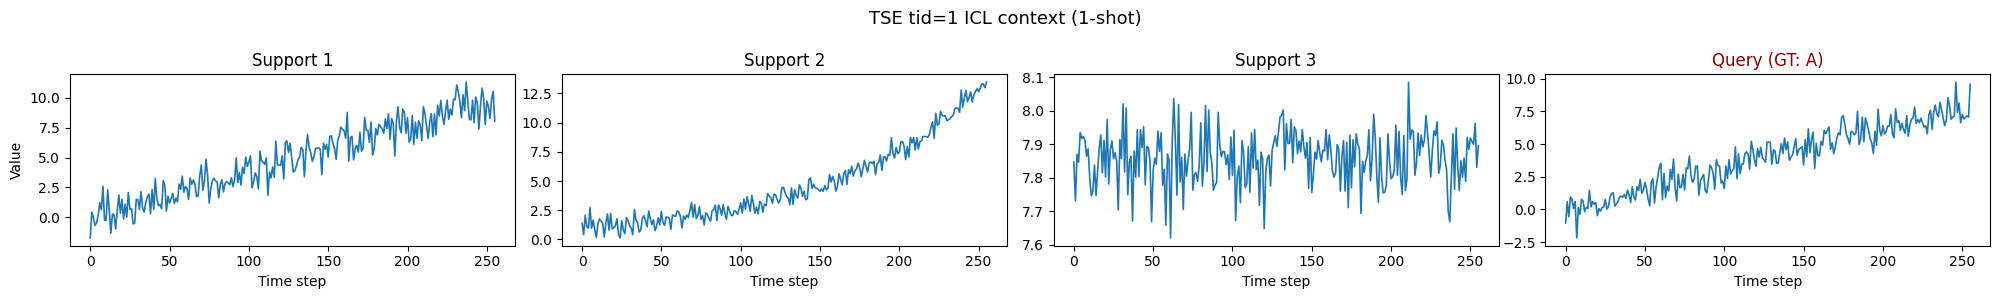

In [54]:
# Visualise support + query for TSE single-series
ts_list = sample_tse['input_ts']
n_support = len(ts_list) - 1

fig, axes = plt.subplots(1, len(ts_list), figsize=(5 * len(ts_list), 3), sharey=False)
if len(ts_list) == 1:
    axes = [axes]
fig.suptitle(f"TSE tid={TID} ICL context (1-shot)", fontsize=13)

for i, (ax, ts) in enumerate(zip(axes, ts_list)):
    inner = ts[0] if isinstance(ts[0], list) else ts
    ax.plot(inner, linewidth=1.2)
    if i < n_support:
        ax.set_title(f"Support {i+1}")
    else:
        ax.set_title(f"Query (GT: {sample_tse['output_text']})", color="darkred")
    ax.set_xlabel("Time step")
axes[0].set_ylabel("Value")
plt.tight_layout()
plt.show()

### 2b. Single-series template (tid=65) — anomaly type

In [55]:
TID2 = 65

tse2_train = TimeSeriesExamDataset(TSE_PATH, tid=TID2, split="train", test_fraction=0.3, seed=42)
tse2_test  = TimeSeriesExamDataset(TSE_PATH, tid=TID2, split="test",  test_fraction=0.3, seed=42)

print(f"tid={TID2} | Train: {len(tse2_train)} | Test: {len(tse2_test)}")
print(f"is_two_series : {tse2_train.is_two_series}")
print(f"label_names   : {tse2_train.label_names}")
print(f"option_texts  : {tse2_train.option_texts}")
print()
print("Description:")
print(tse2_train.desc)

tid=65 | Train: 6 | Test: 4
is_two_series : False
label_names   : ['A', 'B']
option_texts  : ['Cutoff: the pattern of time series disappeared for certain point in time and became flat', 'Scale: the pattern is at obviously different scale at certain point in time']

Description:
Question: The following time series has an anomaly. What is the most likely type of anomaly?

Options:
A) Cutoff: the pattern of time series disappeared for certain point in time and became flat
B) Scale: the pattern is at obviously different scale at certain point in time


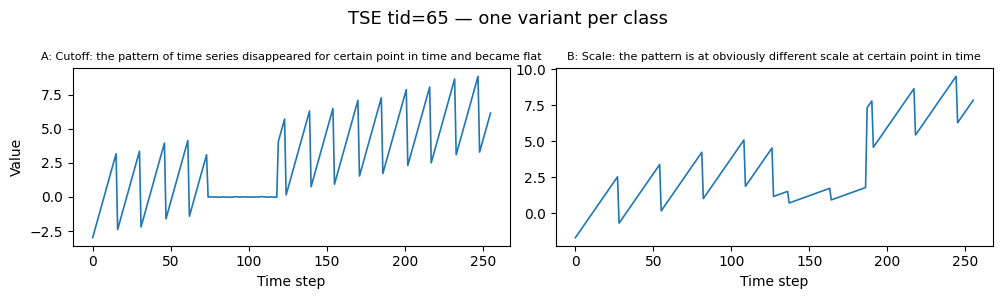

In [56]:
# One sample per class
seen2 = {}
for i in range(len(tse2_train)):
    ts, label = tse2_train[i]
    lv = label.item()
    if lv not in seen2:
        seen2[lv] = ts.numpy()
    if len(seen2) == len(tse2_train.label_names):
        break

fig, axes = plt.subplots(1, len(seen2), figsize=(5 * len(seen2), 3), sharey=False)
fig.suptitle(f"TSE tid={TID2} — one variant per class", fontsize=13)
for ax, (lv, ts) in zip(axes, sorted(seen2.items())):
    letter = tse2_train.label_names[lv]
    opt_text = tse2_train.option_texts[lv]
    ax.plot(ts, linewidth=1.2)
    ax.set_title(f"{letter}: {opt_text}", fontsize=8)
    ax.set_xlabel("Time step")
axes[0].set_ylabel("Value")
plt.tight_layout()
plt.show()

In [57]:
# Build 1-shot ICL prompt for tid=65
args_tse2 = SimpleNamespace(
    picking_strategy="first",
    num_shots=1,
    random_seed=0,
    use_label_desc=1,
    desc_dir="ucr_descriptions",
    num_samples=5,
    input_mode="combined",
)

icl_tse2 = ICLUCRDataset.from_ucr_dataset(
    tse2_train, tse2_test,
    task_id=f"icl_tse_{TID2}",
    args=args_tse2,
)

sample_tse2 = icl_tse2[0]
print(f"=== ICL TSE PROMPT (tid={TID2}, first test sample) ===")
print(f"Ground-truth label : {sample_tse2['output_text']}")
print(f"Options            : {sample_tse2['options']}")
print()
prompt_display = re.sub(r"\[([^\[\]]+)\]", shorten_array, sample_tse2['input_text'])
print(prompt_display)

=== ICL TSE PROMPT (tid=65, first test sample) ===
Ground-truth label : A
Options            : ['A', 'B']

Time Series Classification.
Question: The following time series has an anomaly. What is the most likely type of anomaly?

Options:
A) Cutoff: the pattern of time series disappeared for certain point in time and became flat
B) Scale: the pattern is at obviously different scale at certain point in time

--- EXAMPLES ---

Example 1 Time Series: [-2.9780, -2.5685, -2.1590, -1.7495, -1.3400, -0.9305, -0.5210, -0.1115, ... (256 values)]
Label: A

Example 2 Time Series: [-1.6867, -1.5302, -1.3737, -1.2172, -1.0607, -0.9042, -0.7476, -0.5911, ... (256 values)]
Label: B

--- TARGET ---
New Time Series: [-2.5677, -2.2291, -1.8904, -1.5518, -1.2132, -0.8746, -0.5360, -0.1974, ... (256 values)]
Return ONLY the label as one of: [A, B] without any explanation



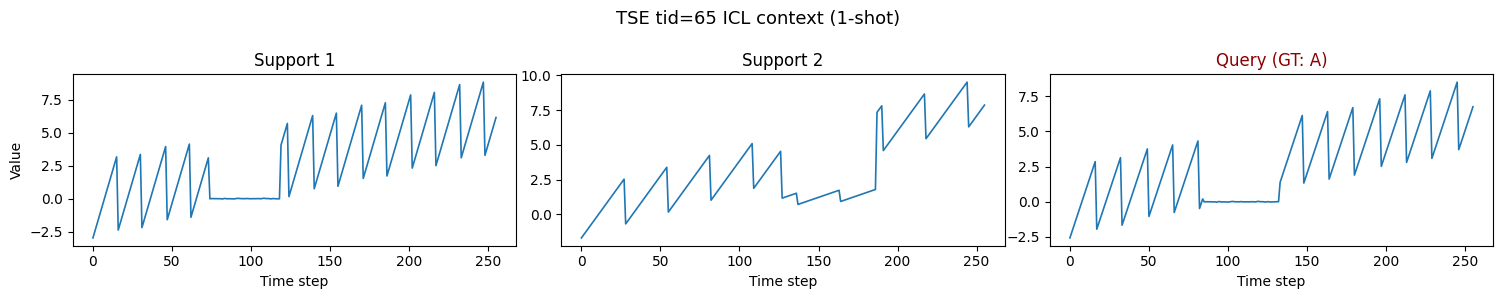

In [58]:
# Visualise support + query for tid=65
ts_list2 = sample_tse2['input_ts']
n_support2 = len(ts_list2) - 1

fig, axes = plt.subplots(1, len(ts_list2), figsize=(5 * len(ts_list2), 3), sharey=False)
if len(ts_list2) == 1:
    axes = [axes]
fig.suptitle(f"TSE tid={TID2} ICL context (1-shot)", fontsize=13)

for i, (ax, ts) in enumerate(zip(axes, ts_list2)):
    inner = ts[0] if isinstance(ts[0], list) else ts
    ax.plot(inner, linewidth=1.2)
    if i < n_support2:
        ax.set_title(f"Support {i+1}")
    else:
        ax.set_title(f"Query (GT: {sample_tse2['output_text']})", color="darkred")
    ax.set_xlabel("Time step")
axes[0].set_ylabel("Value")
plt.tight_layout()
plt.show()

---
## 3. TSE — Two-Series Query Example (from `qa_dataset.json`)

Two-series templates are not yet in `qa_dataset_augmented.json`, but the original question bank
has many of them (tids 44–102). Each entry has `ts1` and `ts2` fields instead of a single `ts`.

We use **tid=60** — *"Which time series has higher noise?"* — which has 4 entries across 2 classes.
We show one example per class and then build a 1-shot ICL prompt manually from the raw data.

In [59]:
QA_PATH = "qa_dataset.json"
TID_2S = 60

with open(QA_PATH) as f:
    qa_all = json.load(f)

entries_2s = [e for e in qa_all if e["tid"] == TID_2S]
print(f"tid={TID_2S} | Total entries: {len(entries_2s)}")
print(f"Question : {entries_2s[0]['question']}")
print(f"Options  : {entries_2s[0]['options']}")
print()

# Group by answer class
by_answer = {}
for e in entries_2s:
    ans = e["answer"]
    by_answer.setdefault(ans, []).append(e)

print("Classes found:")
for ans, items in by_answer.items():
    print(f"  '{ans}' — {len(items)} example(s)")

tid=60 | Total entries: 4
Question : You are given two time series with same underlying pattern but different noise level (variance). Which time series has higher magnitude of noise?
Options  : ['Time series 1', 'Time series 2']

Classes found:
  'Time series 1' — 2 example(s)
  'Time series 2' — 2 example(s)


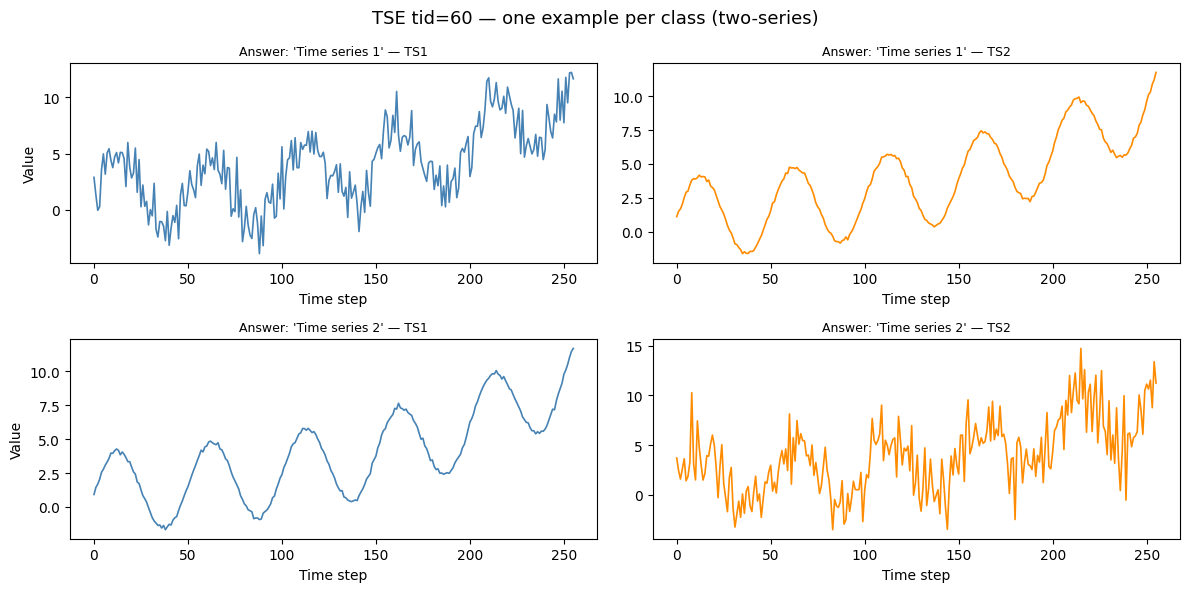

In [60]:
# Plot one example per class — each has TS1 (blue) and TS2 (orange) side by side
classes = sorted(by_answer.keys())
fig, axes = plt.subplots(len(classes), 2, figsize=(12, 3 * len(classes)))
fig.suptitle(f"TSE tid={TID_2S} — one example per class (two-series)", fontsize=13)

for row, cls in enumerate(classes):
    entry = by_answer[cls][0]
    ts1 = np.array(entry["ts1"])
    ts2 = np.array(entry["ts2"])
    axes[row][0].plot(ts1, linewidth=1.2, color="steelblue")
    axes[row][0].set_title(f"Answer: '{cls}' — TS1", fontsize=9)
    axes[row][0].set_xlabel("Time step")
    axes[row][0].set_ylabel("Value")
    axes[row][1].plot(ts2, linewidth=1.2, color="darkorange")
    axes[row][1].set_title(f"Answer: '{cls}' — TS2", fontsize=9)
    axes[row][1].set_xlabel("Time step")

plt.tight_layout()
plt.show()

In [61]:
# Build a 1-shot two-series ICL prompt manually
# Use first example of each class as support, second example of first class as query
options = entries_2s[0]["options"]
option_letters = list("ABCDEFGHIJ"[:len(options)])
answer_to_letter = {opt: letter for letter, opt in zip(option_letters, options)}

# Build question description
desc_lines = "\n".join(f"{l}) {o}" for l, o in zip(option_letters, options))
desc = f"Question: {entries_2s[0]['question']}\n\nOptions:\n{desc_lines}"

# Pick one support per class and one query
support_examples = [by_answer[cls][0] for cls in classes]
query_entry = by_answer[classes[0]][1]   # second example of first class

def fmt_ts(ts, n=8):
    vals = [f"{v:.4f}" for v in ts]
    short = ", ".join(vals[:n])
    return f"[{short}, ... ({len(vals)} values)]"

prompt = f"Time Series Classification.\n{desc}\n\n--- EXAMPLES ---\n"
for i, ex in enumerate(support_examples):
    letter = answer_to_letter[ex["answer"]]
    prompt += f"\nExample {i+1} Time Series 1: {fmt_ts(ex['ts1'])}\n"
    prompt += f"Example {i+1} Time Series 2: {fmt_ts(ex['ts2'])}\n"
    prompt += f"Label: {letter}\n"

options_str = "[" + ", ".join(option_letters) + "]"
prompt += f"\n--- TARGET ---\n"
prompt += f"New Time Series 1: {fmt_ts(query_entry['ts1'])}\n"
prompt += f"New Time Series 2: {fmt_ts(query_entry['ts2'])}\n"
prompt += f"Return ONLY the label as one of: {options_str} without any explanation\n"

gt_letter = answer_to_letter[query_entry["answer"]]
print(f"=== ICL TWO-SERIES PROMPT (tid={TID_2S}) ===")
print(f"Ground-truth label : {gt_letter} ({query_entry['answer']})")
print()
print(prompt)

=== ICL TWO-SERIES PROMPT (tid=60) ===
Ground-truth label : A (Time series 1)

Time Series Classification.
Question: You are given two time series with same underlying pattern but different noise level (variance). Which time series has higher magnitude of noise?

Options:
A) Time series 1
B) Time series 2

--- EXAMPLES ---

Example 1 Time Series 1: [2.8917, 1.3358, -0.0387, 0.2709, 3.5628, 4.9784, 3.1721, 5.0585, ... (256 values)]
Example 1 Time Series 2: [1.1135, 1.5138, 1.6830, 2.0308, 2.5253, 2.9184, 2.9990, 3.4565, ... (256 values)]
Label: A

Example 2 Time Series 1: [0.9163, 1.4386, 1.6812, 2.0401, 2.5501, 2.7824, 3.0758, 3.3129, ... (256 values)]
Example 2 Time Series 2: [3.6897, 2.4128, 1.5657, 2.6047, 3.6130, 1.3975, 1.8373, 3.2693, ... (256 values)]
Label: B

--- TARGET ---
New Time Series 1: [-1.1014, 1.8204, 2.1827, 3.3646, 5.5915, 2.4257, 0.1694, 2.3123, ... (256 values)]
New Time Series 2: [1.0178, 1.4274, 1.7510, 1.9906, 2.5249, 2.8854, 3.1762, 3.2799, ... (256 values)]
R

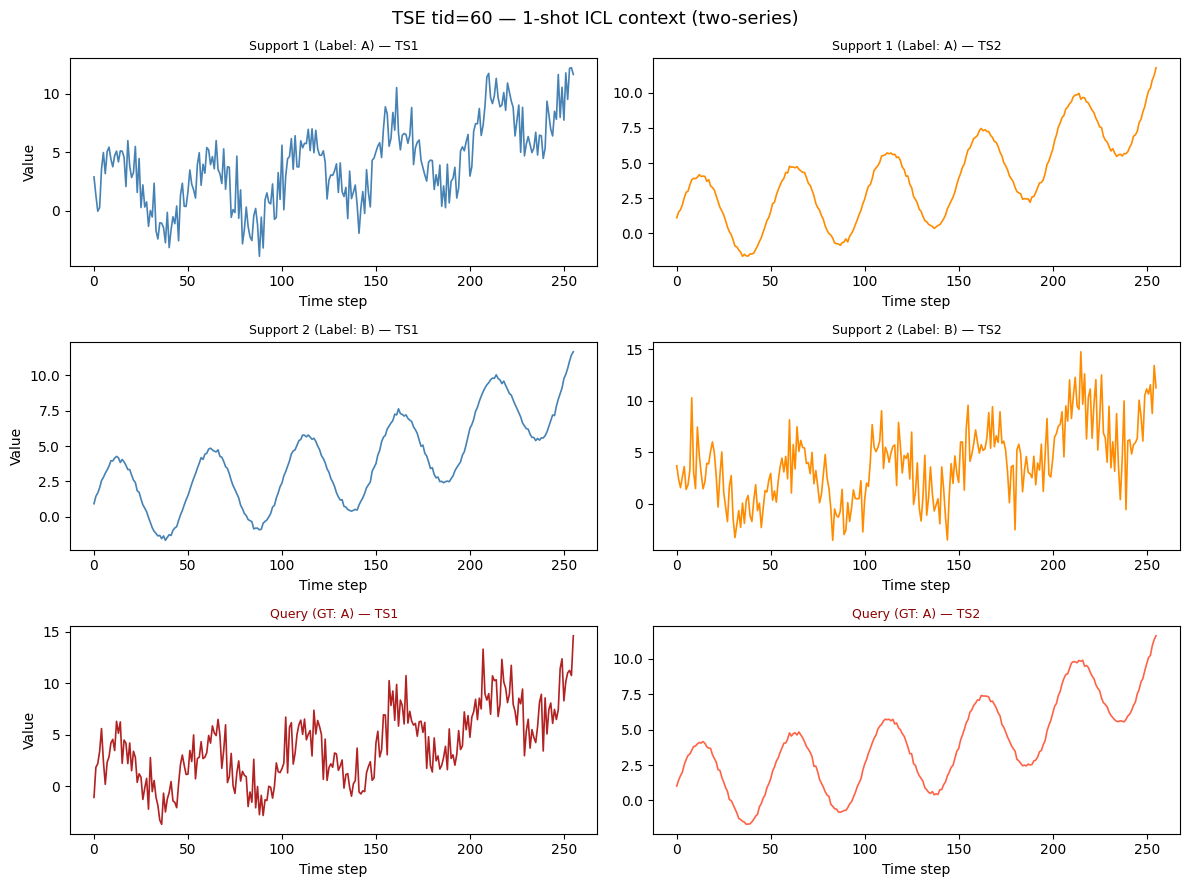

In [62]:
# Visualise: support examples (rows) and query (last row), each with TS1 and TS2
all_examples = support_examples + [query_entry]
n_rows = len(all_examples)

fig, axes = plt.subplots(n_rows, 2, figsize=(12, 3 * n_rows))
fig.suptitle(f"TSE tid={TID_2S} — 1-shot ICL context (two-series)", fontsize=13)

for row, ex in enumerate(all_examples):
    is_query = (row == n_rows - 1)
    ts1 = np.array(ex["ts1"])
    ts2 = np.array(ex["ts2"])
    label = answer_to_letter[ex["answer"]]
    title_suffix = f"Query (GT: {label})" if is_query else f"Support {row+1} (Label: {label})"
    title_color = "darkred" if is_query else "black"
    c1 = "firebrick" if is_query else "steelblue"
    c2 = "tomato"   if is_query else "darkorange"
    axes[row][0].plot(ts1, linewidth=1.2, color=c1)
    axes[row][0].set_title(f"{title_suffix} — TS1", fontsize=9, color=title_color)
    axes[row][0].set_xlabel("Time step")
    axes[row][0].set_ylabel("Value")
    axes[row][1].plot(ts2, linewidth=1.2, color=c2)
    axes[row][1].set_title(f"{title_suffix} — TS2", fontsize=9, color=title_color)
    axes[row][1].set_xlabel("Time step")

plt.tight_layout()
plt.show()